In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('results.csv')

<h1>EDA</h1>

In [3]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
df.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49500,2026-07-07,Switzerland,Colombia,0.0,0.0,FIFA World Cup,Vancouver,Canada,True
49501,2026-07-09,France,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49502,2026-07-10,Spain,Belgium,NaN,NaN,FIFA World Cup,Inglewood,United States,True
49503,2026-07-11,Norway,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49504,2026-07-11,Argentina,Switzerland,NaN,NaN,FIFA World Cup,Kansas City,United States,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49505 entries, 0 to 49504
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49505 non-null  object 
 1   home_team   49505 non-null  object 
 2   away_team   49505 non-null  object 
 3   home_score  49501 non-null  float64
 4   away_score  49501 non-null  float64
 5   tournament  49505 non-null  object 
 6   city        49505 non-null  object 
 7   country     49505 non-null  object 
 8   neutral     49505 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [6]:
df.describe()

,home_score,away_score
count,49501.000000,49501.000000
mean,1.757197,1.181936
std,1.773821,1.401655
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


There is a outliners of 31 goal(highly unusal)

In [7]:
q1=df['home_score'].quantile(0.25)
q3=df['home_score'].quantile(0.75)
q1_a=df['away_score'].quantile(0.25)
q3_a=df['away_score'].quantile(0.75)

In [8]:
iqr=q3-q1
lwrbd=q1-1.5*iqr
uprbd=q3+1.5*iqr

In [9]:
iqr

np.float64(1.0)

In [10]:
uprbd

np.float64(3.5)

In [11]:
iqr_a=q3_a-q1_a
lwrbd_a=q1_a-1.5*iqr_a
uprbd_a=q3_a+1.5*iqr_a

In [12]:
uprbd_a

np.float64(5.0)

we did iqr method for outliners detection but we came up only 3.5 goals which is not very unusal
so we will manually set outliners as 10 goals

In [13]:
np.where(df['home_score']>10)

(array([   56,   121,   133,   234,   362,   518,   572,  1191,  1194,
         1283,  1298,  1705,  1761,  2301,  2544,  2623,  2657,  2858,
         2897,  2900,  2903,  3129,  3358,  3434,  3985,  4140,  5562,
         5955,  5960,  6025,  6580,  6589,  6849,  7126,  7682,  8342,
         8551,  9070,  9451,  9866, 10262, 11267, 11318, 11916, 11919,
        11921, 11930, 12131, 12843, 12850, 12906, 13984, 14387, 16668,
        17955, 18677, 19015, 19470, 19478, 19479, 19481, 19581, 19600,
        19918, 20530, 20532, 20545, 21525, 21957, 22002, 22051, 22709,
        22715, 23054, 23094, 23661, 24088, 24094, 24181, 24201, 24651,
        25083, 25086, 25407, 25422, 25424, 25425, 25428, 25438, 25441,
        25513, 25514, 25537, 25757, 26522, 26883, 27007, 27336, 27340,
        27357, 27366, 27381, 27589, 27783, 27805, 27997, 28146, 28821,
        28822, 28825, 29153, 29810, 29886, 30512, 30518, 30595, 30988,
        31182, 31184, 31656, 33231, 34116, 34267, 34724, 35120, 35579,
      

In [14]:
array=[   56,   121,   133,   234,   362,   518,   572,  1191,  1194,
         1283,  1298,  1705,  1761,  2301,  2544,  2623,  2657,  2858,
         2897,  2900,  2903,  3129,  3358,  3434,  3985,  4140,  5562,
         5955,  5960,  6025,  6580,  6589,  6849,  7126,  7682,  8342,
         8551,  9070,  9451,  9866, 10262, 11267, 11318, 11916, 11919,
        11921, 11930, 12131, 12843, 12850, 12906, 13984, 14387, 16668,
        17955, 18677, 19015, 19470, 19478, 19479, 19481, 19581, 19600,
        19918, 20530, 20532, 20545, 21525, 21957, 22002, 22051, 22709,
        22715, 23054, 23094, 23661, 24088, 24094, 24181, 24201, 24651,
        25083, 25086, 25407, 25422, 25424, 25425, 25428, 25438, 25441,
        25513, 25514, 25537, 25757, 26522, 26883, 27007, 27336, 27340,
        27357, 27366, 27381, 27589, 27783, 27805, 27997, 28146, 28821,
        28822, 28825, 29153, 29810, 29886, 30512, 30518, 30595, 30988,
        31182, 31184, 31656, 33231, 34116, 34267, 34724, 35120, 35579,
        35890, 36119, 36246, 36262, 37059, 37061, 37110, 39008, 39292,
        40560, 41795, 41841, 41925, 42759, 42766, 43032, 43168, 43891,
        44013, 46738, 46845, 48673]

In [15]:
for i in array:
  df.loc[i,['home_score']]=9

In [16]:
np.where(df['away_score']>10)

(array([   19,   231,   238,   371,   502,   504,  2218,  2280,  5623,
         5904,  6008,  6537,  7766,  8546,  8552, 10240, 11920, 12140,
        13803, 13808, 15922, 17940, 17960, 18417, 20541, 21484, 21956,
        21962, 21996, 22048, 22940, 23228, 23244, 23669, 25434, 27346,
        27349, 27408, 29040, 29045, 30279, 31192, 35146, 35173, 35901,
        36270, 37066, 37792, 37797, 37827, 39708, 42738, 42757, 42765,
        43860]),)

In [17]:
array_away=[   19,   231,   238,   371,   502,   504,  2218,  2280,  5623,
         5904,  6008,  6537,  7766,  8546,  8552, 10240, 11920, 12140,
        13803, 13808, 15922, 17940, 17960, 18417, 20541, 21484, 21956,
        21962, 21996, 22048, 22940, 23228, 23244, 23669, 25434, 27346,
        27349, 27408, 29040, 29045, 30279, 31192, 35146, 35173, 35901,
        36270, 37066, 37792, 37797, 37827, 39708, 42738, 42757, 42765,
        43860]

In [18]:
for i in array:
  df.loc[i,['away_score']]=9

We see that the upcoming matches are filled with null values so we will delete it andd futher handles other null values

In [19]:
df.isnull().sum()

,0
date,0
home_team,0
away_team,0
home_score,4
away_score,4
tournament,0
city,0
country,0
neutral,0


In [20]:
df=df.dropna()

In [21]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
49496,False
49497,False
49498,False
49499,False


<h1>Feature Engineering</h1>

In feature engineering we will add some columns like home team rank , away team rank ,rank diff, goal ratio etc .

In [22]:
#this is offically taken form the current fifa standing(date:2026/7/8)
fifa_ranking=['Argentina', 'Spain', 'France', 'England', 'Portugal', 'Brazil',
              'Morocco', 'Netherlands', 'Belgium', 'Germany', 'Croatia', 'Italy',
              'Colombia', 'Mexico', 'Senegal', 'Uruguay', 'USA', 'Japan', 'Switzerland',
              'Iran', 'Denmark', 'Türkiye', 'Ecuador', 'Austria', 'South Korea', 'Nigeria',
              'Australia', 'Algeria', 'Egypt', 'Canada', 'Norway', 'Ukraine', "Côte d'Ivoire",
              'Panama', 'Russia', 'Poland', 'Wales', 'Sweden', 'Hungary', 'Czechia', 'Paraguay', 'Scotland',
              'Serbia', 'Cameroon', 'Tunisia', 'DR Congo', 'Slovakia', 'Greece', 'Venezuela', 'Uzbekistan',
              'Chile', 'Peru', 'Costa Rica', 'Romania', 'Mali', 'Qatar', 'Iraq', 'Ireland',
              'Slovenia', 'South Africa',
              'Saudi Arabia', 'Burkina Faso', 'Jordan', 'Bosnia & Herzegovina', 'Honduras', 'Albania', 'Cape Verde', 'United Arab Emirates', 'North Macedonia', 'Northern Ireland']


now we will add three columns the home team ranking , away team ranking and difference

In [23]:
ranking_dict = {team.title(): idx + 1 for idx, team in enumerate(fifa_ranking)}

In [24]:
ranking_dict

{'Argentina': 1,
 'Spain': 2,
 'France': 3,
 'England': 4,
 'Portugal': 5,
 'Brazil': 6,
 'Morocco': 7,
 'Netherlands': 8,
 'Belgium': 9,
 'Germany': 10,
 'Croatia': 11,
 'Italy': 12,
 'Colombia': 13,
 'Mexico': 14,
 'Senegal': 15,
 'Uruguay': 16,
 'Usa': 17,
 'Japan': 18,
 'Switzerland': 19,
 'Iran': 20,
 'Denmark': 21,
 'Türkiye': 22,
 'Ecuador': 23,
 'Austria': 24,
 'South Korea': 25,
 'Nigeria': 26,
 'Australia': 27,
 'Algeria': 28,
 'Egypt': 29,
 'Canada': 30,
 'Norway': 31,
 'Ukraine': 32,
 "Côte D'Ivoire": 33,
 'Panama': 34,
 'Russia': 35,
 'Poland': 36,
 'Wales': 37,
 'Sweden': 38,
 'Hungary': 39,
 'Czechia': 40,
 'Paraguay': 41,
 'Scotland': 42,
 'Serbia': 43,
 'Cameroon': 44,
 'Tunisia': 45,
 'Dr Congo': 46,
 'Slovakia': 47,
 'Greece': 48,
 'Venezuela': 49,
 'Uzbekistan': 50,
 'Chile': 51,
 'Peru': 52,
 'Costa Rica': 53,
 'Romania': 54,
 'Mali': 55,
 'Qatar': 56,
 'Iraq': 57,
 'Ireland': 58,
 'Slovenia': 59,
 'South Africa': 60,
 'Saudi Arabia': 61,
 'Burkina Faso': 62,
 'Jor

In [25]:
df['home_team_ranking']=df['home_team'].str.title().map(ranking_dict)

In [26]:
df['away_team_ranking']=df['away_team'].str.title().map(ranking_dict)

In [27]:
df['home_team_ranking']=df['home_team_ranking'].fillna(200).astype(int)
df['away_team_ranking']=df['away_team_ranking'].fillna(200).astype(int)

In [28]:
df['rank_diff']=df['home_team_ranking']-df['away_team_ranking']

In [29]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_team_ranking,away_team_ranking,rank_diff
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,42,4,38
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,4,42,-38
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,42,4,38
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,4,42,-38
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,42,4,38


now we will take the ratio of goal score and goal conceded for it we will take the data from only 3 year(wc qualifier)

In [30]:
df['date']=pd.to_datetime(df['date'])

In [31]:
indices = np.where(df['date'] > pd.to_datetime('2023-01-10'))


In [32]:
indices

(array([45825, 45826, 45827, ..., 49498, 49499, 49500]),)

In [33]:
index=45825

In [34]:
recent_df=df[df.index>index].copy()

In [35]:
home_stat=recent_df.groupby('home_team').agg(
     home_goals_scored=('home_score', 'sum'),
    home_goals_conceded=('away_score', 'sum'),
    home_matches=('home_score', 'count')
)

In [36]:
away_stat=recent_df.groupby('away_team').agg(
    away_goals_scored=('away_score', 'sum'),
    away_goals_conceded=('home_score', 'sum'),
    away_matches=('away_score', 'count')
)

In [37]:
team_stat=home_stat.join(away_stat,how='outer').fillna(0)

In [38]:
team_stat

,home_goals_scored,home_goals_conceded,home_matches,away_goals_scored,away_goals_conceded,away_matches
Afghanistan,2.0,10.0,8.0,10.0,28.0,14.0
Albania,24.0,14.0,19.0,16.0,18.0,17.0
Algeria,72.0,27.0,31.0,42.0,16.0,22.0
American Samoa,2.0,12.0,2.0,11.0,30.0,5.0
Andorra,6.0,20.0,15.0,5.0,40.0,20.0
...,...,...,...,...,...,...
Ynys Môn,5.0,5.0,3.0,8.0,2.0,3.0
Zambia,21.0,14.0,16.0,21.0,32.0,19.0
Zanzibar,4.0,2.0,4.0,0.0,0.0,0.0
Zimbabwe,10.0,13.0,10.0,13.0,18.0,16.0


Now we will add some columns like goal_scored ratio and goal conceded ratio

In [39]:
team_stat['total_matches'] = team_stat['home_matches'] + team_stat['away_matches']
team_stat['goals_scored_ratio'] = (team_stat['home_goals_scored'] + team_stat['away_goals_scored']) / team_stat['total_matches']
team_stat['goals_conceded_ratio'] = (team_stat['home_goals_conceded'] + team_stat['away_goals_conceded']) / team_stat['total_matches']
scored_dict=team_stat['goals_scored_ratio'].to_dict()
conceded_dict=team_stat['goals_conceded_ratio'].to_dict()


In [40]:
df['home_team_goals_scored_ratio'] = df['home_team'].map(scored_dict)
df['home_team_goals_conceded_ratio'] = df['home_team'].map(conceded_dict)

df['away_team_goals_scored_ratio'] = df['away_team'].map(scored_dict)
df['away_team_goals_conceded_ratio'] = df['away_team'].map(conceded_dict)

df[['home_team_goals_scored_ratio', 'home_team_goals_conceded_ratio',
    'away_team_goals_scored_ratio', 'away_team_goals_conceded_ratio']] = df[[
    'home_team_goals_scored_ratio', 'home_team_goals_conceded_ratio',
    'away_team_goals_scored_ratio', 'away_team_goals_conceded_ratio']].fillna(0)


now we will make a target label

In [41]:
df['target']=(df['home_score'] > df['away_score']).astype(int)

In [42]:
df['target']

,target
0,0
1,1
2,1
3,0
4,1
...,...
49496,0
49497,0
49498,0
49499,1


In [43]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_team_ranking,away_team_ranking,rank_diff,home_team_goals_scored_ratio,home_team_goals_conceded_ratio,away_team_goals_scored_ratio,away_team_goals_conceded_ratio,target
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,42,4,38,1.500000,1.425000,2.108696,0.608696,0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,4,42,-38,2.108696,0.608696,1.500000,1.425000,1
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,42,4,38,1.500000,1.425000,2.108696,0.608696,1
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,4,42,-38,2.108696,0.608696,1.500000,1.425000,0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,42,4,38,1.500000,1.425000,2.108696,0.608696,1


now we will drop some columns to prevent data leakage

In [44]:
df=df.drop(columns=['date',	'home_team', 'away_team','home_score','away_score'])

In [45]:
df=df.drop(columns=['city', 'country','tournament'])

In [46]:
df.isnull().sum()

,0
neutral,0
home_team_ranking,0
away_team_ranking,0
rank_diff,0
home_team_goals_scored_ratio,0
home_team_goals_conceded_ratio,0
away_team_goals_scored_ratio,0
away_team_goals_conceded_ratio,0
target,0


now we will encode the categorical data

In [47]:
from sklearn.preprocessing import OrdinalEncoder
encode=OrdinalEncoder()
df['neutral'] = encode.fit_transform(df[['neutral']])

In [48]:
df.head()

,neutral,home_team_ranking,away_team_ranking,rank_diff,home_team_goals_scored_ratio,home_team_goals_conceded_ratio,away_team_goals_scored_ratio,away_team_goals_conceded_ratio,target
0,0.0,42,4,38,1.500000,1.425000,2.108696,0.608696,0
1,0.0,4,42,-38,2.108696,0.608696,1.500000,1.425000,1
2,0.0,42,4,38,1.500000,1.425000,2.108696,0.608696,1
3,0.0,4,42,-38,2.108696,0.608696,1.500000,1.425000,0
4,0.0,42,4,38,1.500000,1.425000,2.108696,0.608696,1


now we will go for building model

In [50]:
y=df['target']
df=df.drop(columns=['target'])
X=df

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

we will use boosting algorithm

In [52]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [53]:
model=XGBClassifier(random_state=42)

In [54]:
model.fit(X_train,y_train)
pred=model.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score,precision_score,recall_score

In [56]:
accuracy_score(y_test, pred)

0.6750833249166751

In [57]:
precision_score(y_test, pred)

0.6759493670886076

In [58]:
recall_score(y_test, pred)

0.6558853633572159

In [61]:
from sklearn.model_selection import KFold
cv = KFold(

n_splits=5,

shuffle=True,

random_state=42
)

In [62]:
params = {

'n_estimators':[100,200,300,500],

'max_depth':[3,4,5,6,8],

'learning_rate':[0.3,0.1,0.05,0.01],

'subsample':[0.6,0.8,1],

'colsample_bytree':[0.6,0.8,1],

'gamma':[0,0.1,0.2,0.5],

'min_child_weight':[1,3,5],

'reg_alpha':[0,0.1,1],

'reg_lambda':[1,5,10]
}


In [63]:
random = RandomizedSearchCV(

XGBClassifier(random_state=42),

param_distributions=params,

n_iter=50,

cv=5,

scoring="f1",

random_state=42,

n_jobs=-1
)

In [64]:
random.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1],
                                        'gamma': [0, 0.1, 0.2, 0.5],
                                        'learning_rate': [0.3, 0.1, 0.05, 0.01],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'reg_alpha': [0, 0.1, 1],
                                        'reg_lambda': [1, 5, 10],
                                        'subsample': [0.6, 0.8, 1]},
                   random_state=42, scoring='f1')

In [65]:
best_model = random.best_estimator_

In [66]:
best_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [68]:
prediction = best_model.predict(X_test)

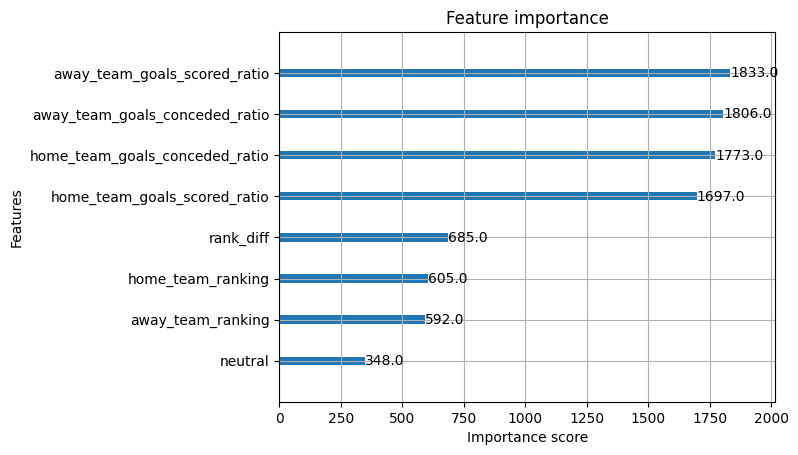

In [69]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(best_model)

plt.show()

In [71]:
import joblib

joblib.dump(best_model, "xgb_model.pkl")

['xgb_model.pkl']

In [70]:
accuracy_score(y_test, pred)

0.6750833249166751

In [72]:
X

,neutral,home_team_ranking,away_team_ranking,rank_diff,home_team_goals_scored_ratio,home_team_goals_conceded_ratio,away_team_goals_scored_ratio,away_team_goals_conceded_ratio
0,0.0,42,4,38,1.500000,1.425000,2.108696,0.608696
1,0.0,4,42,-38,2.108696,0.608696,1.500000,1.425000
2,0.0,42,4,38,1.500000,1.425000,2.108696,0.608696
3,0.0,4,42,-38,2.108696,0.608696,1.500000,1.425000
4,0.0,42,4,38,1.500000,1.425000,2.108696,0.608696
...,...,...,...,...,...,...,...,...
49496,0.0,14,4,10,1.580645,0.903226,2.108696,0.608696
49497,1.0,5,2,3,2.444444,0.800000,2.543478,0.739130
49498,0.0,200,9,191,1.966102,1.220339,2.325581,0.860465
49499,1.0,1,29,-28,2.250000,0.431818,1.634615,0.807692
